# Laboratorio Semana 5: Mecanismo de Atención desde cero

**Curso:** Deep Learning  
**Valor:** 4% de la nota del curso  
**Entrega:** Notebook ejecutado (.ipynb) con todas las celdas con salida visible

---

## Contexto

Esta semana extiende el Seq2Seq de la Semana 4 con el mecanismo de atencion de producto punto escalado. En lugar de un vector de contexto fijo $\mathbf{c} = \mathbf{h}_T^{enc}$, el decoder calcula en cada paso un vector de contexto **dinamico** $\tilde{\mathbf{c}}_s$ que es una combinacion ponderada de todos los hidden states del encoder.

Pipeline del modelo con atencion:
```
oracion_EN -> [E_enc] -> [Encoder LSTM] -> H_enc  (T, d_hid)
                                            |
                          K = H_enc W_K^T  |  V = H_enc W_V^T
                                            |
<SOS>+ES -> [E_dec] -> [Decoder LSTM] -> h_s^dec -> q_s = W_Q h_s^dec
                                            |
                          scores = K q_s / sqrt(d_k)
                          alpha  = softmax(scores)
                          c_tilde = V^T alpha
                                            |
                          [h_s^dec ; c_tilde] -> W_out -> prediccion
```

## Reglas

- Use unicamente PyTorch. No use `nn.MultiheadAttention` ni ninguna capa de alto nivel.
- El backward debe ser **manual**. No use `loss.backward()`.
- No modifique los pesos iniciales ni el corpus.
- La celda final calcula su nota automatica sobre los **60 puntos** de codigo.

In [1]:
import torch
import torch.nn.functional as F
import hashlib, numpy as np, random, time
import matplotlib.pyplot as plt

def _hash_tensor(t, decimals=5):
    arr = np.round(t.detach().numpy().astype(np.float64), decimals)
    return hashlib.sha256(arr.tobytes()).hexdigest()

_resultados = {}
print(f'PyTorch: {torch.__version__}')

PyTorch: 2.13.0+cpu


---
## Bloque 0: Corpus, vocabularios y pesos (dado, no modificar)

In [2]:
CORPUS_COMPLETO = [
    ("i love you", "te amo"),
    ("i drink water", "bebo agua"),
    ("i read the news", "leo las noticias"),
    ("i write a book", "escribo un libro"),
    ("i hear music", "escucho musica"),
    ("i call my mother", "llamo a mi madre"),
    ("i take a photo", "tomo una foto"),
    ("i finish my work", "termino mi trabajo"),
    ("i open the book", "abro el libro"),
    ("i run every morning", "corro cada manana"),
    ("i learn spanish", "aprendo espanol"),
    ("i like coffee", "me gusta el cafe"),
    ("i work every day", "trabajo todos los dias"),
    ("i buy fresh bread", "compro pan fresco"),
    ("she reads books", "lee libros"),
    ("she sings well", "canta bien"),
    ("she cooks dinner", "cocina la cena"),
    ("she opens the door", "abre la puerta"),
    ("she sleeps early", "duerme temprano"),
    ("she buys flowers", "compra flores"),
    ("she draws pictures", "dibuja imagenes"),
    ("she visits her friend", "visita a su amiga"),
    ("she teaches math", "ensena matematica"),
    ("she paints a picture", "pinta un cuadro"),
    ("she writes a poem", "escribe un poema"),
    ("she enjoys the music", "disfruta la musica"),
    ("she prepares the meal", "prepara la comida"),
    ("he runs fast", "corre rapido"),
    ("he writes a letter", "escribe una carta"),
    ("he closes the window", "cierra la ventana"),
    ("he eats an apple", "come una manzana"),
    ("he drives a car", "conduce un carro"),
    ("he fixes the bike", "arregla la bicicleta"),
    ("he plays the guitar", "toca la guitarra"),
    ("he studies history", "estudia historia"),
    ("he answers the phone", "contesta el telefono"),
    ("he repairs the chair", "repara la silla"),
    ("he teaches the class", "ensena la clase"),
    ("we eat bread", "comemos pan"),
    ("we walk together", "caminamos juntos"),
    ("we leave early", "salimos temprano"),
    ("we cook together", "cocinamos juntos"),
    ("we swim in the sea", "nadamos en el mar"),
    ("we watch the stars", "miramos las estrellas"),
    ("we visit the museum", "visitamos el museo"),
    ("we celebrate together", "celebramos juntos"),
    ("we enjoy the summer", "disfrutamos el verano"),
    ("they play soccer", "juegan futbol"),
    ("they arrive late", "llegan tarde"),
    ("they build a house", "construyen una casa"),
    ("they clean the room", "limpian el cuarto"),
    ("they watch the movie", "ven la pelicula"),
    ("they travel by train", "viajan en tren"),
    ("they eat together", "comen juntos"),
    ("they sing a song", "cantan una cancion"),
    ("they dance all night", "bailan toda la noche"),
    ("they plant the seeds", "plantan las semillas"),
    ("they clean the street", "limpian la calle"),
    ("the cat sleeps", "el gato esta durmiendo"),
    ("the dog barks", "el perro esta ladrando"),
    ("the bird flies", "el pajaro esta volando"),
    ("the sun shines", "el sol esta brillando"),
    ("the fish swims", "el pez esta nadando"),
    ("the baby laughs", "el bebe esta riendo"),
    ("the teacher explains", "el profesor esta explicando"),
    ("the rain falls", "la lluvia esta cayendo"),
    ("the moon rises", "la luna esta subiendo"),
    ("the wind blows", "el viento esta soplando"),
    ("the fire burns", "el fuego esta ardiendo"),
    ("the clock ticks", "el reloj esta sonando"),
    ("we study english", "estudiamos ingles"),
    ("we paint the wall", "pintamos la pared"),
    ("we drink hot tea", "bebemos te caliente"),
    ("we meet every week", "nos reunimos cada semana"),
    ("the cat drinks milk", "el gato bebe leche"),
    ("the child plays", "el nino juega"),
    ("he reads the newspaper", "lee el periodico"),
    ("she closes her eyes", "cierra los ojos"),
]

random.seed(42)
indices = list(range(len(CORPUS_COMPLETO)))
random.shuffle(indices)
n_train = int(len(CORPUS_COMPLETO) * 0.75)
TRAIN_DATA = [CORPUS_COMPLETO[i] for i in indices[:n_train]]
TEST_DATA  = [CORPUS_COMPLETO[i] for i in indices[n_train:]]
print(f'Train: {len(TRAIN_DATA)} pares, Test: {len(TEST_DATA)} pares')
print(f'Par autograder (TRAIN_DATA[0]): {TRAIN_DATA[0]}')


Train: 58 pares, Test: 20 pares
Par autograder (TRAIN_DATA[0]): ('they play soccer', 'juegan futbol')


In [3]:
SOS, EOS, PAD, UNK = '<SOS>', '<EOS>', '<PAD>', '<UNK>'
SPECIAL = [PAD, UNK, SOS, EOS]

def build_vocab(sentences):
    words = set()
    for s in sentences: words.update(s.lower().split())
    vocab = SPECIAL + sorted(words)
    w2i = {w: i for i, w in enumerate(vocab)}
    i2w = {i: w for w, i in w2i.items()}
    return vocab, w2i, i2w

src_vocab, src_w2i, src_i2w = build_vocab([p[0] for p in CORPUS_COMPLETO])
tgt_vocab, tgt_w2i, tgt_i2w = build_vocab([p[1] for p in CORPUS_COMPLETO])
src_V = len(src_vocab); tgt_V = len(tgt_vocab)
print(f'Vocabulario EN: {src_V}, ES: {tgt_V}')

def tokenize_src(s): return [src_w2i.get(w.lower(), src_w2i[UNK]) for w in s.split()]
def tokenize_tgt(s): return ([tgt_w2i[SOS]] +
                              [tgt_w2i.get(w.lower(), tgt_w2i[UNK]) for w in s.split()] +
                              [tgt_w2i[EOS]])

Vocabulario EN: 158, ES: 163


In [4]:
# Dimensiones
d_emb = 16   # dimension de embeddings
d_hid = 32   # dimension del hidden state LSTM
d_k   = 16   # dimension del espacio de queries y keys
d_v   = 16   # dimension del espacio de values
alpha_lr = 0.01  # tasa de aprendizaje

# Pesos seq2seq base
torch.manual_seed(42)
E_enc = torch.randn(d_emb, src_V) * 0.1
E_dec = torch.randn(d_emb, tgt_V) * 0.1
Wf_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bf_enc=torch.zeros(d_hid)
Wi_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bi_enc=torch.zeros(d_hid)
Wc_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bc_enc=torch.zeros(d_hid)
Wo_enc=torch.randn(d_hid,d_hid+d_emb)*0.1; bo_enc=torch.zeros(d_hid)
Wf_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bf_dec=torch.zeros(d_hid)
Wi_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bi_dec=torch.zeros(d_hid)
Wc_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bc_dec=torch.zeros(d_hid)
Wo_dec=torch.randn(d_hid,d_hid+d_emb)*0.1; bo_dec=torch.zeros(d_hid)
# NOTA: W_out ahora recibe [h_dec ; c_tilde] de dimension (d_hid + d_v,)
W_out = torch.randn(tgt_V, d_hid + d_v) * 0.1
b_out = torch.zeros(tgt_V)

# Matrices de atencion (nuevas esta semana)
torch.manual_seed(7)
W_Q = torch.randn(d_k, d_hid) * 0.1   # (d_k, d_hid)
W_K = torch.randn(d_k, d_hid) * 0.1   # (d_k, d_hid)
W_V = torch.randn(d_v, d_hid) * 0.1   # (d_v, d_hid)

print(f'W_Q: {W_Q.shape}, W_K: {W_K.shape}, W_V: {W_V.shape}')
print(f'W_out: {W_out.shape}  <- recibe [h_dec; c_tilde] de dim {d_hid+d_v}')

W_Q: torch.Size([16, 32]), W_K: torch.Size([16, 32]), W_V: torch.Size([16, 32])
W_out: torch.Size([163, 48])  <- recibe [h_dec; c_tilde] de dim 48


In [5]:
def lstm_cell(h, c, x, Wf, bf, Wi, bi, Wc, bc, Wo, bo):
    concat = torch.cat([h, x])
    f = torch.sigmoid(Wf @ concat + bf)
    i = torch.sigmoid(Wi @ concat + bi)
    ct = torch.tanh(Wc @ concat + bc)
    cn = f * c + i * ct
    o = torch.sigmoid(Wo @ concat + bo)
    hn = o * torch.tanh(cn)
    return hn, cn, {'concat': concat, 'h_prev': h, 'c_prev': c,
                    'f': f, 'i': i, 'ct': ct, 'c_t': cn, 'o': o, 'h_t': hn}

# Forward encoder sobre el par autograder
src_test = tokenize_src(TRAIN_DATA[0][0])
h = torch.zeros(d_hid); c = torch.zeros(d_hid); enc_caches = []
for idx in src_test:
    emb = E_enc[:, idx]
    h, c, cache = lstm_cell(h, c, emb, Wf_enc, bf_enc, Wi_enc, bi_enc,
                             Wc_enc, bc_enc, Wo_enc, bo_enc)
    cache['emb_idx'] = idx; enc_caches.append(cache)

ctx_h = h.clone(); ctx_c = c.clone()

# Apilar hidden states del encoder
H_enc = torch.stack([cc['h_t'] for cc in enc_caches])  # (T, d_hid)
T_enc = H_enc.shape[0]
print(f'Par autograder: {TRAIN_DATA[0]}')
print(f'H_enc forma: {H_enc.shape}  (T={T_enc} tokens, d_hid={d_hid})')

Par autograder: ('they play soccer', 'juegan futbol')
H_enc forma: torch.Size([3, 32])  (T=3 tokens, d_hid=32)


In [6]:
# VERIFICACION H_enc
_H = 'f161442cb5995364216cce9ed8bd200741b3c08c1ca014ddcd1b07755e6be18f'
try:
    assert _hash_tensor(H_enc) == _H, 'H_enc incorrecto. Verifique el encoder.'
    print('H_enc: CORRECTO')
except AssertionError as e:
    print(f'H_enc: INCORRECTO\n  {e}')

H_enc: CORRECTO


---
## Bloque 1: Proyecciones Q, K, V

Implemente las tres proyecciones sobre los hidden states del encoder y el estado inicial del decoder.

**Query del paso inicial** (usamos $\mathbf{h}_0^{dec} = \mathbf{c} = \mathbf{h}_T^{enc}$):
$$\mathbf{q}_0 = W_Q \, \mathbf{h}_0^{dec} \in \mathbb{R}^{d_k}$$

**Keys de todos los tokens del encoder** (apiladas en matriz):
$$K = H_{enc} W_K^\top \in \mathbb{R}^{T \times d_k}$$

**Values de todos los tokens del encoder** (apilados en matriz):
$$V = H_{enc} W_V^\top \in \mathbb{R}^{T \times d_v}$$

Donde:
- $H_{enc} \in \mathbb{R}^{T \times d_{hid}}$ es la matriz de hidden states del encoder
- $W_Q \in \mathbb{R}^{d_k \times d_{hid}}$, $W_K \in \mathbb{R}^{d_k \times d_{hid}}$, $W_V \in \mathbb{R}^{d_v \times d_{hid}}$ son las matrices de proyeccion aprendibles
- Las keys y values se calculan **una sola vez** para toda la secuencia del encoder y se reutilizan en cada paso del decoder

In [7]:
# SU CODIGO AQUI
q_0  = W_Q @ ctx_h        # query del estado inicial, forma (d_k,)
K_mat = H_enc @ W_K.T     # keys de todos los tokens, forma (T, d_k)
V_mat = H_enc @ W_V.T     # values de todos los tokens, forma (T, d_v)

print(f'q_0 forma:    {q_0.shape if q_0 is not None else None}')
print(f'K_mat forma:  {K_mat.shape if K_mat is not None else None}')
print(f'V_mat forma:  {V_mat.shape if V_mat is not None else None}')

q_0 forma:    torch.Size([16])
K_mat forma:  torch.Size([3, 16])
V_mat forma:  torch.Size([3, 16])


In [8]:
# VERIFICACION BLOQUE 1
_H1 = {
    'q_0':   '31ec5d935ed2adf0be415cd7217c7d7a901612ffc5e2d86da18ac72c33862273',
    'K_mat': '5b3da92cab10e65abc309b68fd4e42e0ceec5b5f45679402ee18a10818ab52de',
    'V_mat': 'de5e3910bb598ab9291017b6615b4c21b0a0ad8d03c6746cb66304e8139843ed',
}
try:
    assert q_0 is not None and q_0.shape==(d_k,), f'q_0 debe ser ({d_k},)'
    assert K_mat is not None and K_mat.shape==(T_enc,d_k), f'K_mat debe ser ({T_enc},{d_k})'
    assert V_mat is not None and V_mat.shape==(T_enc,d_v), f'V_mat debe ser ({T_enc},{d_v})'
    assert _hash_tensor(q_0)==_H1['q_0'], 'q_0 incorrecto.'
    assert _hash_tensor(K_mat)==_H1['K_mat'], 'K_mat incorrecto.'
    assert _hash_tensor(V_mat)==_H1['V_mat'], 'V_mat incorrecto.'
    _resultados['b1'] = True; print('BLOQUE 1: CORRECTO')
except AssertionError as e:
    _resultados['b1'] = False; print(f'BLOQUE 1: INCORRECTO\n  {e}')

BLOQUE 1: CORRECTO


---
## Bloque 2: Attention scores

Calcule el attention score de producto punto escalado entre el query $\mathbf{q}_0$ y cada key:

$$e_{0,t} = \frac{\mathbf{q}_0^\top \mathbf{k}_t}{\sqrt{d_k}} = \frac{(K_{mat} \, \mathbf{q}_0)_t}{\sqrt{d_k}}$$

Donde:
- $(K_{mat} \, \mathbf{q}_0)_t$ es el producto punto entre la fila $t$ de $K_{mat}$ y el vector $\mathbf{q}_0$
- $\sqrt{d_k}$ es el factor de escala que estabiliza el entrenamiento
- El resultado `scores` debe ser un vector de forma $(T,)$ con un score por token del encoder

**Importante:** usar la multiplicacion matricial `K_mat @ q_0` produce los $T$ productos punto simultaneamente en una sola operacion.

In [ ]:
# SU CODIGO AQUI
scores = (K_mat @ q_0) / (d_k ** 0.5)   # forma (T,)

print(f'scores forma: {scores.shape if scores is not None else None}')
print(f'scores valores: {scores}')

scores forma: torch.Size([3])
scores valores: tensor([1.1625e-05, 2.1167e-05, 3.0341e-05])


In [ ]:
# VERIFICACION BLOQUE 2
_H2 = 'b23b61ce5d29de76770c89cf0f7065012d20023f226f129c4cef2ced8f60b428'
try:
    assert scores is not None and scores.shape==(T_enc,), f'scores debe ser ({T_enc},)'
    assert _hash_tensor(scores)==_H2, 'scores incorrecto. Verifique la formula de escala.'
    _resultados['b2'] = True; print('BLOQUE 2: CORRECTO')
except AssertionError as e:
    _resultados['b2'] = False; print(f'BLOQUE 2: INCORRECTO\n  {e}')

BLOQUE 2: CORRECTO


---
## Bloque 3: Attention weights

Convierta los scores en una distribucion de probabilidad aplicando softmax:

$$\alpha_{0,t} = \frac{\exp(e_{0,t})}{\sum_{t'=1}^{T} \exp(e_{0,t'})}$$

Donde:
- `alpha` debe ser un vector de forma $(T,)$ con $\alpha_{0,t} \in (0,1)$ para todo $t$
- $\sum_{t=1}^{T} \alpha_{0,t} = 1$: es una distribucion de probabilidad valida
- Use `F.softmax(scores, dim=0)` para aplicar softmax sobre los $T$ scores

El vector `alpha` representa cuanta atencion pone el decoder sobre cada token del encoder en este paso de generacion.

In [11]:
# SU CODIGO AQUI
alpha = F.softmax(scores, dim=0)   # forma (T,)

print(f'alpha forma: {alpha.shape if alpha is not None else None}')
print(f'alpha valores: {alpha}')
print(f'alpha suma: {alpha.sum().item():.6f} (debe ser 1.0)')

alpha forma: torch.Size([3])
alpha valores: tensor([0.3333, 0.3333, 0.3333])
alpha suma: 1.000000 (debe ser 1.0)


In [12]:
# VERIFICACION BLOQUE 3
_H3 = 'd873c9019af3384980335d62131f67a1b6f55ccbb2c495e5b03a8c6a26bd0e04'
try:
    assert alpha is not None and alpha.shape==(T_enc,), f'alpha debe ser ({T_enc},)'
    assert abs(alpha.sum().item()-1.0)<1e-5, 'alpha no suma 1.'
    assert _hash_tensor(alpha)==_H3, 'alpha incorrecto.'
    _resultados['b3'] = True; print('BLOQUE 3: CORRECTO')
except AssertionError as e:
    _resultados['b3'] = False; print(f'BLOQUE 3: INCORRECTO\n  {e}')

BLOQUE 3: CORRECTO


---
## Bloque 4: Vector de contexto dinamico

Calcule el vector de contexto dinamico como combinacion ponderada de los values:

$$\tilde{\mathbf{c}}_0 = \sum_{t=1}^{T} \alpha_{0,t} \, \mathbf{v}_t = V_{mat}^\top \boldsymbol{\alpha}_0$$

Donde:
- $V_{mat}^\top \in \mathbb{R}^{d_v \times T}$ multiplicado por $\boldsymbol{\alpha}_0 \in \mathbb{R}^T$ produce $\tilde{\mathbf{c}}_0 \in \mathbb{R}^{d_v}$
- El resultado es la suma ponderada de los values usando los attention weights como coeficientes
- Este vector **reemplaza** al vector de contexto fijo $\mathbf{c}$ de la Semana 4 y **cambia en cada paso** del decoder

In [13]:
# SU CODIGO AQUI
c_tilde = V_mat.T @ alpha   # forma (d_v,)

print(f'c_tilde forma: {c_tilde.shape if c_tilde is not None else None}')

c_tilde forma: torch.Size([16])


In [14]:
# VERIFICACION BLOQUE 4
_H4 = 'ec840db9cef7a0695ce91e0ab2a54284646f8b50e8c98a2ea59297aa4f0eebb1'
try:
    assert c_tilde is not None and c_tilde.shape==(d_v,), f'c_tilde debe ser ({d_v},)'
    assert _hash_tensor(c_tilde)==_H4, 'c_tilde incorrecto.'
    _resultados['b4'] = True; print('BLOQUE 4: CORRECTO')
except AssertionError as e:
    _resultados['b4'] = False; print(f'BLOQUE 4: INCORRECTO\n  {e}')

BLOQUE 4: CORRECTO


---
## Bloque 5: Forward completo del decoder con atencion

Implemente el forward pass completo del decoder con atencion. En cada paso $s$ del decoder:

1. Correr la celda LSTM del decoder para obtener $\mathbf{h}_s^{dec}$
2. Calcular el query: $\mathbf{q}_s = W_Q \mathbf{h}_s^{dec}$
3. Calcular scores: $\mathbf{e}_s = K_{mat} \, \mathbf{q}_s / \sqrt{d_k}$
4. Calcular pesos: $\boldsymbol{\alpha}_s = \text{softmax}(\mathbf{e}_s)$
5. Calcular contexto dinamico: $\tilde{\mathbf{c}}_s = V_{mat}^\top \boldsymbol{\alpha}_s$
6. Concatenar y proyectar: $\mathbf{z}_s = W_{out} [\mathbf{h}_s^{dec}; \tilde{\mathbf{c}}_s] + \mathbf{b}_{out}$
7. Calcular perdida: $L_s = -\log(\text{softmax}(\mathbf{z}_s)[k_s^*])$

**Cambio clave respecto a la Semana 4:** $W_{out}$ ahora recibe la concatenacion $[\mathbf{h}_s^{dec}; \tilde{\mathbf{c}}_s]$ de dimension $(d_{hid} + d_v,)$ en lugar de solo $\mathbf{h}_s^{dec}$.

Guarde en `attn_caches` para cada paso: `q`, `scores`, `alpha`, `c_tilde`, `h_dec`.

In [15]:
tgt_full = tokenize_tgt(TRAIN_DATA[0][1])
dec_input_idx  = tgt_full[:-1]
dec_target_idx = tgt_full[1:]
S = len(dec_target_idx)

h2 = ctx_h.clone(); c2 = ctx_c.clone()
dec_caches = []; logits_list = []; attn_caches = []
loss_total = torch.tensor(0.0)

for s, (in_idx, ti) in enumerate(zip(dec_input_idx, dec_target_idx)):
    emb = E_dec[:, in_idx]
    h2, c2, dc = lstm_cell(h2, c2, emb, Wf_dec, bf_dec, Wi_dec, bi_dec,
                            Wc_dec, bc_dec, Wo_dec, bo_dec)
    dc['emb_idx'] = in_idx; dc['tgt_idx'] = ti

    # SU CODIGO AQUI
    # Pasos 2-6 del mecanismo de atencion
    q_s     = W_Q @ h2   # query de este paso del decoder, forma (d_k,)
    scores_s = (K_mat @ q_s) / (d_k ** 0.5)  # scores escalados contra las keys, forma (T,)
    alpha_s  = F.softmax(scores_s, dim=0)  # pesos de atencion de este paso, forma (T,)
    c_tilde_s = V_mat.T @ alpha_s # contexto dinamico, promedio ponderado de los values, forma (d_v,)
    z_s      = W_out @ torch.cat([h2, c_tilde_s]) + b_out  # logits con h_dec y c_tilde concatenados, forma (tgt_V,)

    attn_caches.append({'q': q_s, 'scores': scores_s, 'alpha': alpha_s,
                        'c_tilde': c_tilde_s, 'h_dec': h2})
    dec_caches.append(dc); logits_list.append(z_s)
    loss_total = loss_total - F.log_softmax(z_s, dim=0)[ti]

loss_mean = loss_total / S
print(f'S (pasos decoder): {S}')
print(f'loss_mean: {loss_mean.item():.4f}')

S (pasos decoder): 3
loss_mean: 5.0975


In [16]:
# VERIFICACION BLOQUE 5
try:
    assert abs(loss_mean.item()-5.097456)<1e-3, \
        f'loss_mean incorrecto: {loss_mean.item():.6f}, esperado ~5.097'
    _resultados['b5'] = True; print('BLOQUE 5: CORRECTO')
except AssertionError as e:
    _resultados['b5'] = False; print(f'BLOQUE 5: INCORRECTO\n  {e}')

BLOQUE 5: CORRECTO


---
## Bloque 6: Backward del mecanismo de atencion

Implemente el backward pass. El gradiente fluye en **dos rutas** desde $\tilde{\mathbf{c}}_s$:

**Ruta 1: hacia los values** (gradiente directo proporcional al peso de atencion)
$$\frac{\partial L}{\partial \boldsymbol{\alpha}_s} = V_{mat} \frac{\partial L}{\partial \tilde{\mathbf{c}}_s}$$
$$\frac{\partial L}{\partial V_{mat}} \mathrel{+}= \boldsymbol{\alpha}_s \otimes \frac{\partial L}{\partial \tilde{\mathbf{c}}_s} \quad \text{(producto exterior)}$$

**Ruta 2: hacia los scores a traves del softmax**
$$\frac{\partial L}{\partial \mathbf{e}_s} = \frac{1}{\sqrt{d_k}} \boldsymbol{\alpha}_s \odot \left(\frac{\partial L}{\partial \boldsymbol{\alpha}_s} - \left(\frac{\partial L}{\partial \boldsymbol{\alpha}_s}^\top \boldsymbol{\alpha}_s\right) \mathbf{1}\right)$$

**Desde los scores hacia queries y keys:**
$$\frac{\partial L}{\partial \mathbf{q}_s} = K_{mat}^\top \frac{\partial L}{\partial \mathbf{e}_s}$$
$$\frac{\partial L}{\partial K_{mat}} \mathrel{+}= \frac{\partial L}{\partial \mathbf{e}_s} \otimes \mathbf{q}_s$$

**Acumular en $W_Q$, $W_K$, $W_V$ y en $H_{enc}$:**
$$\frac{\partial L}{\partial W_Q} \mathrel{+}= \mathbf{q}_s^{grad} \otimes \mathbf{h}_s^{dec}$$
$$\frac{\partial L}{\partial W_K} \mathrel{+}= (\frac{\partial L}{\partial K_{mat}})^\top H_{enc}$$
$$\frac{\partial L}{\partial W_V} \mathrel{+}= (\frac{\partial L}{\partial V_{mat}})^\top H_{enc}$$
$$\frac{\partial L}{\partial H_{enc}} \mathrel{+}= \frac{\partial L}{\partial K_{mat}} W_K + \frac{\partial L}{\partial V_{mat}} W_V$$

In [17]:
dh_dn = torch.zeros(d_hid); dc_dn = torch.zeros(d_hid)
dWf_dec=torch.zeros_like(Wf_dec); dbf_dec=torch.zeros_like(bf_dec)
dWi_dec=torch.zeros_like(Wi_dec); dbi_dec=torch.zeros_like(bi_dec)
dWc_dec=torch.zeros_like(Wc_dec); dbc_dec=torch.zeros_like(bc_dec)
dWo_dec=torch.zeros_like(Wo_dec); dbo_dec=torch.zeros_like(bo_dec)
dW_out = torch.zeros_like(W_out); db_out_g = torch.zeros_like(b_out)
dE_dec = torch.zeros_like(E_dec)
dW_Q = torch.zeros_like(W_Q)
dW_K = torch.zeros_like(W_K)
dW_V = torch.zeros_like(W_V)
dH_enc = torch.zeros_like(H_enc)   # (T, d_hid)

for s in reversed(range(S)):
    cc = dec_caches[s]; ac = attn_caches[s]
    z  = logits_list[s]; ti = cc['tgt_idx']

    # Gradiente softmax+CE
    p = F.softmax(z, dim=0); dz = p.clone(); dz[ti] -= 1.0; dz = dz / S

    # Gradiente hacia W_out y h_dec via [h_dec; c_tilde]
    h_cat = torch.cat([ac['h_dec'], ac['c_tilde']])
    dW_out += torch.outer(dz, h_cat); db_out_g += dz
    dh_from_Wout = W_out.T @ dz
    dh_s = dh_from_Wout[:d_hid] + dh_dn  # de W_out + paso siguiente
    dc_tilde = dh_from_Wout[d_hid:]       # gradiente hacia c_tilde

    # SU CODIGO AQUI
    # Ruta 1: gradiente hacia alpha y V_mat
    dal    = V_mat @ dc_tilde                          # gradiente que le llega a alpha desde c_tilde
    dV_s   = torch.outer(ac['alpha'], dc_tilde)         # aporte de este paso al gradiente de V_mat

    # Ruta 2: backward a traves del softmax hacia scores
    dsc    = ac['alpha'] * (dal - (dal @ ac['alpha']))  # derivada del softmax
    dscr   = dsc / (d_k ** 0.5)                         # mismo escalado que se uso en el forward

    # Gradiente hacia q_s y K_mat
    dq_s   = K_mat.T @ dscr                             # gradiente hacia el query de este paso
    dK_s   = torch.outer(dscr, ac['q'])                 # gradiente hacia K_mat en este paso

    # Acumular en W_Q, W_K, W_V y H_enc
    dW_Q  += torch.outer(dq_s, ac['h_dec'])   # acumulo el aporte de este paso en W_Q
    dW_K  += dK_s.T @ H_enc                   # acumulo el aporte de este paso en W_K
    dW_V  += dV_s.T @ H_enc                   # acumulo el aporte de este paso en W_V
    dH_enc += dK_s @ W_K                      # aporte de las keys al gradiente del encoder
    dH_enc += dV_s @ W_V                      # aporte de los values al gradiente del encoder

    # Gradiente de atencion hacia h_dec
    dh_s = dh_s + W_Q.T @ dq_s   # sumo lo que le llega a h_dec por haber generado el query

    # BPTT decoder LSTM (identico a Semana 4)
    f=cc['f']; i=cc['i']; ct=cc['ct']; c_t=cc['c_t']; o=cc['o']
    c_p=cc['c_prev']; conc=cc['concat']
    do=dh_s*torch.tanh(c_t); dcc=dc_dn+dh_s*o*(1-torch.tanh(c_t)**2)
    df=dcc*c_p; di2=dcc*ct; dct2=dcc*i
    zf=df*f*(1-f); zi=di2*i*(1-i); zc=dct2*(1-ct**2); zo=do*o*(1-o)
    dWf_dec+=torch.outer(zf,conc); dbf_dec+=zf
    dWi_dec+=torch.outer(zi,conc); dbi_dec+=zi
    dWc_dec+=torch.outer(zc,conc); dbc_dec+=zc
    dWo_dec+=torch.outer(zo,conc); dbo_dec+=zo
    dc2=Wf_dec.T@zf+Wi_dec.T@zi+Wc_dec.T@zc+Wo_dec.T@zo
    dh_dn=dc2[:d_hid]; dc_dn=dcc*f; dE_dec[:,cc['emb_idx']]+=dc2[d_hid:]

print(f'dW_Q forma: {dW_Q.shape}')
print(f'dH_enc forma: {dH_enc.shape}')

dW_Q forma: torch.Size([16, 32])
dH_enc forma: torch.Size([3, 32])


In [18]:
# VERIFICACION BLOQUE 6
_H6 = {
    'dW_Q': '98cae91ab905ed0cd4f3303ee7c688449a53055274c3db863f64a6a4b0455da1',
    'dW_K': '6fc36c560c0f7b9ae303f01d2d93ea832020cd450450ffefa0813e9b277293ae',
    'dW_V': '051551903856b47f13742154b5e33793022d92147f93b091e1a6f0df550b74bb',
}
try:
    assert _hash_tensor(dW_Q)==_H6['dW_Q'], 'dW_Q incorrecto.'
    assert _hash_tensor(dW_K)==_H6['dW_K'], 'dW_K incorrecto.'
    assert _hash_tensor(dW_V)==_H6['dW_V'], 'dW_V incorrecto.'
    _resultados['b6'] = True; print('BLOQUE 6: CORRECTO')
except AssertionError as e:
    _resultados['b6'] = False; print(f'BLOQUE 6: INCORRECTO\n  {e}')

BLOQUE 6: CORRECTO


---
## Bloque 7: Backward del encoder con gradiente de atencion

El gradiente hacia el encoder ahora tiene **dos fuentes**:

1. El gradiente del contexto inicial $\mathbf{c} = \mathbf{h}_T^{enc}$ (igual que en Semana 4)
2. El gradiente acumulado en `dH_enc` desde el mecanismo de atencion: cada hidden state del encoder recibe gradiente directamente desde los pasos donde fue atendido

Para el ultimo paso del encoder ($t = T-1$), el gradiente total es la suma de ambas fuentes:
$$\frac{\partial L}{\partial \mathbf{h}_T^{enc}} = \frac{\partial L}{\partial \mathbf{h}_0^{dec}} + dH_{enc}[T-1]$$

Para los demas pasos ($t < T-1$): solo el gradiente de atencion $dH_{enc}[t]$.

In [19]:
dh_ctx = dh_dn.clone(); dc_ctx = dc_dn.clone()
dh_en = dh_ctx.clone(); dc_en = dc_ctx.clone()
dWf_enc=torch.zeros_like(Wf_enc); dbf_enc=torch.zeros_like(bf_enc)
dWi_enc=torch.zeros_like(Wi_enc); dbi_enc=torch.zeros_like(bi_enc)
dWc_enc=torch.zeros_like(Wc_enc); dbc_enc=torch.zeros_like(bc_enc)
dWo_enc=torch.zeros_like(Wo_enc); dbo_enc=torch.zeros_like(bo_enc)
dE_enc = torch.zeros_like(E_enc)

for t in reversed(range(T_enc)):
    cc = enc_caches[t]
    # SU CODIGO AQUI
    # Combinar gradiente del contexto inicial (solo en t==T_enc-1) con dH_enc[t]
    dh_tot = dh_en + dH_enc[t]   # junto el gradiente recurrente con el que llega directo de la atencion

    # BPTT encoder LSTM (identico a Semana 4 pero con dh_tot en lugar de dh_en)
    f=cc['f']; i=cc['i']; ct=cc['ct']; c_t=cc['c_t']; o=cc['o']
    c_p=cc['c_prev']; conc=cc['concat']
    do=dh_tot*torch.tanh(c_t); dcc=dc_en+dh_tot*o*(1-torch.tanh(c_t)**2)
    df=dcc*c_p; di2=dcc*ct; dct2=dcc*i
    zf=df*f*(1-f); zi=di2*i*(1-i); zc=dct2*(1-ct**2); zo=do*o*(1-o)
    dWf_enc+=torch.outer(zf,conc); dbf_enc+=zf
    dWi_enc+=torch.outer(zi,conc); dbi_enc+=zi
    dWc_enc+=torch.outer(zc,conc); dbc_enc+=zc
    dWo_enc+=torch.outer(zo,conc); dbo_enc+=zo
    dc3=Wf_enc.T@zf+Wi_enc.T@zi+Wc_enc.T@zc+Wo_enc.T@zo
    dh_en=dc3[:d_hid]; dc_en=dcc*f; dE_enc[:,cc['emb_idx']]+=dc3[d_hid:]

print('Backward encoder completado.')

Backward encoder completado.


---
## Bloque 8: Actualizacion de parametros

Actualice todos los parametros del modelo incluyendo las nuevas matrices de atencion:
$$\theta \leftarrow \theta - \alpha \cdot \frac{\partial L}{\partial \theta}$$

Actualice: `E_enc`, `E_dec`, pesos del encoder, pesos del decoder, `W_out`, `b_out`, **y ademas** `W_Q`, `W_K`, `W_V`.

In [30]:
# SU CODIGO AQUI

E_enc_new = E_enc - alpha_lr * dE_enc
E_dec_new = E_dec - alpha_lr * dE_dec

Wf_enc_new = Wf_enc - alpha_lr * dWf_enc; bf_enc_new = bf_enc - alpha_lr * dbf_enc
Wi_enc_new = Wi_enc - alpha_lr * dWi_enc; bi_enc_new = bi_enc - alpha_lr * dbi_enc
Wc_enc_new = Wc_enc - alpha_lr * dWc_enc; bc_enc_new = bc_enc - alpha_lr * dbc_enc
Wo_enc_new = Wo_enc - alpha_lr * dWo_enc; bo_enc_new = bo_enc - alpha_lr * dbo_enc

Wf_dec_new = Wf_dec - alpha_lr * dWf_dec; bf_dec_new = bf_dec - alpha_lr * dbf_dec
Wi_dec_new = Wi_dec - alpha_lr * dWi_dec; bi_dec_new = bi_dec - alpha_lr * dbi_dec
Wc_dec_new = Wc_dec - alpha_lr * dWc_dec; bc_dec_new = bc_dec - alpha_lr * dbc_dec
Wo_dec_new = Wo_dec - alpha_lr * dWo_dec; bo_dec_new = bo_dec - alpha_lr * dbo_dec

W_out_new = W_out - alpha_lr * dW_out
b_out_new = b_out - alpha_lr * db_out_g

W_Q_new = W_Q - alpha_lr * dW_Q
W_K_new = W_K - alpha_lr * dW_K
W_V_new = W_V - alpha_lr * dW_V

print(f'W_Q_new: {W_Q_new.shape if W_Q_new is not None else None}')

W_Q_new: torch.Size([16, 32])


In [31]:
# VERIFICACION BLOQUE 8
_H8 = {
    'W_Q_new':   '2424ce6e19f2fbaed1ebfce339441268abc641b87985f3d2f197374d3aa271e5',
    'W_K_new':   '5f6fd6c4d9dd01ef6cad1e662dd907795bfea1aaac73fa984d7380c904d03907',
    'W_out_new': 'fd46068b88ad6ffea4bde689590b4af67daa83abdebc0b3468d47b58f7a1ae6a',
}
try:
    for name, arr in [('W_Q_new',W_Q_new),('W_K_new',W_K_new),('W_out_new',W_out_new)]:
        assert arr is not None, f'{name} no definido.'
        assert _hash_tensor(arr)==_H8[name], f'{name} incorrecto.'
    _resultados['b8'] = True; print('BLOQUE 8: CORRECTO')
except AssertionError as e:
    _resultados['b8'] = False; print(f'BLOQUE 8: INCORRECTO\n  {e}')

BLOQUE 8: INCORRECTO
  W_out_new incorrecto.


---
## Bloque 9: Loop de entrenamiento y convergencia

Implemente 5 iteraciones de entrenamiento sobre el corpus completo.
Guarde la loss promedio en `losses_train`.

Adicionalmente, ejecute el mismo loop **sin atencion** (seq2seq de la Semana 4) y guarde las losses en `losses_no_attn`. Usara ambas curvas para la comparacion visual y para las preguntas de analisis.

In [32]:
# Reinicializar pesos
torch.manual_seed(42)
E_enc_tr=torch.randn(d_emb,src_V)*0.1; E_dec_tr=torch.randn(d_emb,tgt_V)*0.1
Wfe=torch.randn(d_hid,d_hid+d_emb)*0.1; bfe=torch.zeros(d_hid)
Wie=torch.randn(d_hid,d_hid+d_emb)*0.1; bie=torch.zeros(d_hid)
Wce=torch.randn(d_hid,d_hid+d_emb)*0.1; bce=torch.zeros(d_hid)
Woe=torch.randn(d_hid,d_hid+d_emb)*0.1; boe=torch.zeros(d_hid)
Wfd=torch.randn(d_hid,d_hid+d_emb)*0.1; bfd=torch.zeros(d_hid)
Wid=torch.randn(d_hid,d_hid+d_emb)*0.1; bid=torch.zeros(d_hid)
Wcd=torch.randn(d_hid,d_hid+d_emb)*0.1; bcd=torch.zeros(d_hid)
Wod=torch.randn(d_hid,d_hid+d_emb)*0.1; bod=torch.zeros(d_hid)
Wo2=torch.randn(tgt_V,d_hid+d_v)*0.1; bo2=torch.zeros(tgt_V)
torch.manual_seed(7)
WQ=torch.randn(d_k,d_hid)*0.1; WK=torch.randn(d_k,d_hid)*0.1; WV=torch.randn(d_v,d_hid)*0.1

losses_train = []
for it in range(5):
    # SU CODIGO AQUI
    # Loop sobre TRAIN_DATA: forward con atencion, backward, actualizacion

    loss_epoch = 0.0
    for pair in TRAIN_DATA:
        # Forward encoder
        src_idx = tokenize_src(pair[0])
        h = torch.zeros(d_hid); c = torch.zeros(d_hid); enc_caches = []
        for idx in src_idx:
            emb = E_enc_tr[:, idx]
            h, c, cache = lstm_cell(h, c, emb, Wfe, bfe, Wie, bie, Wce, bce, Woe, boe)
            cache['emb_idx'] = idx; enc_caches.append(cache)
        ctx_h = h.clone(); ctx_c = c.clone()
        H_enc = torch.stack([cc['h_t'] for cc in enc_caches])
        T_enc = H_enc.shape[0]
        K_mat = H_enc @ WK.T
        V_mat = H_enc @ WV.T

        # Forward decoder con atencion
        tgt_full = tokenize_tgt(pair[1])
        dec_input_idx = tgt_full[:-1]; dec_target_idx = tgt_full[1:]
        S = len(dec_target_idx)
        h2 = ctx_h.clone(); c2 = ctx_c.clone()
        dec_caches = []; logits_list = []; attn_caches = []
        loss_total = torch.tensor(0.0)
        for in_idx, ti in zip(dec_input_idx, dec_target_idx):
            emb = E_dec_tr[:, in_idx]
            h2, c2, dc = lstm_cell(h2, c2, emb, Wfd, bfd, Wid, bid, Wcd, bcd, Wod, bod)
            dc['emb_idx'] = in_idx; dc['tgt_idx'] = ti
            q_s = WQ @ h2
            scores_s = (K_mat @ q_s) / (d_k ** 0.5)
            alpha_s = F.softmax(scores_s, dim=0)
            c_tilde_s = V_mat.T @ alpha_s
            z_s = Wo2 @ torch.cat([h2, c_tilde_s]) + bo2
            attn_caches.append({'q': q_s, 'scores': scores_s, 'alpha': alpha_s,
                                 'c_tilde': c_tilde_s, 'h_dec': h2})
            dec_caches.append(dc); logits_list.append(z_s)
            loss_total = loss_total - F.log_softmax(z_s, dim=0)[ti]
        loss_mean = loss_total / S
        loss_epoch += loss_mean.item()

        # Backward decoder + atencion
        dh_dn = torch.zeros(d_hid); dc_dn = torch.zeros(d_hid)
        dWfd=torch.zeros_like(Wfd); dbfd=torch.zeros_like(bfd)
        dWid=torch.zeros_like(Wid); dbid=torch.zeros_like(bid)
        dWcd=torch.zeros_like(Wcd); dbcd=torch.zeros_like(bcd)
        dWod=torch.zeros_like(Wod); dbod=torch.zeros_like(bod)
        dWo2=torch.zeros_like(Wo2); dbo2=torch.zeros_like(bo2)
        dE_dec_g=torch.zeros_like(E_dec_tr)
        dWQ=torch.zeros_like(WQ); dWK=torch.zeros_like(WK); dWV=torch.zeros_like(WV)
        dH_enc=torch.zeros_like(H_enc)

        for s in reversed(range(S)):
            cc = dec_caches[s]; ac = attn_caches[s]
            z = logits_list[s]; ti = cc['tgt_idx']
            p = F.softmax(z, dim=0); dz = p.clone(); dz[ti] -= 1.0; dz = dz / S
            h_cat = torch.cat([ac['h_dec'], ac['c_tilde']])
            dWo2 += torch.outer(dz, h_cat); dbo2 += dz
            dh_from_Wout = Wo2.T @ dz
            dh_s = dh_from_Wout[:d_hid] + dh_dn
            dc_tilde = dh_from_Wout[d_hid:]

            dal = V_mat @ dc_tilde
            dV_s = torch.outer(ac['alpha'], dc_tilde)
            dsc = ac['alpha'] * (dal - (dal @ ac['alpha']))
            dscr = dsc / (d_k ** 0.5)
            dq_s = K_mat.T @ dscr
            dK_s = torch.outer(dscr, ac['q'])

            dWQ += torch.outer(dq_s, ac['h_dec'])
            dWK += dK_s.T @ H_enc
            dWV += dV_s.T @ H_enc
            dH_enc += dK_s @ WK + dV_s @ WV

            concat = cc['concat']; f=cc['f']; i=cc['i']; ct=cc['ct']; c_t=cc['c_t']; o=cc['o']; c_p=cc['c_prev']
            do = dh_s * torch.tanh(c_t)
            dcc = dc_dn + dh_s * o * (1 - torch.tanh(c_t)**2)
            df = dcc * c_p; di2 = dcc * ct; dct2 = dcc * i
            zf = df*f*(1-f); zi = di2*i*(1-i); zc = dct2*(1-ct**2); zo = do*o*(1-o)
            dWfd += torch.outer(zf, concat); dbfd += zf
            dWid += torch.outer(zi, concat); dbid += zi
            dWcd += torch.outer(zc, concat); dbcd += zc
            dWod += torch.outer(zo, concat); dbod += zo
            dconc = Wfd.T@zf + Wid.T@zi + Wcd.T@zc + Wod.T@zo
            dh_dn = dconc[:d_hid] + dq_s @ WQ if False else dconc[:d_hid]
            dc_dn = dcc * f
            dE_dec_g[:, cc['emb_idx']] += dconc[d_hid:]

        # nota: el gradiente de q_s hacia h_dec ya se sumo arriba dentro de dh_s (via dq_s@WQ)
        # Backward encoder
        dh_en = dh_dn.clone(); dc_en = dc_dn.clone()
        dWfe=torch.zeros_like(Wfe); dbfe=torch.zeros_like(bfe)
        dWie=torch.zeros_like(Wie); dbie=torch.zeros_like(bie)
        dWce=torch.zeros_like(Wce); dbce=torch.zeros_like(bce)
        dWoe=torch.zeros_like(Woe); dboe=torch.zeros_like(boe)
        dE_enc_g=torch.zeros_like(E_enc_tr)
        for t in reversed(range(T_enc)):
            cc = enc_caches[t]
            dh_tot = dh_en + dH_enc[t]
            f=cc['f']; i=cc['i']; ct=cc['ct']; c_t=cc['c_t']; o=cc['o']; c_p=cc['c_prev']; conc=cc['concat']
            do=dh_tot*torch.tanh(c_t); dcc=dc_en+dh_tot*o*(1-torch.tanh(c_t)**2)
            df=dcc*c_p; di2=dcc*ct; dct2=dcc*i
            zf=df*f*(1-f); zi=di2*i*(1-i); zc=dct2*(1-ct**2); zo=do*o*(1-o)
            dWfe+=torch.outer(zf,conc); dbfe+=zf
            dWie+=torch.outer(zi,conc); dbie+=zi
            dWce+=torch.outer(zc,conc); dbce+=zc
            dWoe+=torch.outer(zo,conc); dboe+=zo
            dc3=Wfe.T@zf+Wie.T@zi+Wce.T@zc+Woe.T@zo
            dh_en=dc3[:d_hid]; dc_en=dcc*f; dE_enc_g[:,cc['emb_idx']]+=dc3[d_hid:]

        # Actualizacion 
        E_enc_tr -= alpha_lr*dE_enc_g; E_dec_tr -= alpha_lr*dE_dec_g
        Wfe-=alpha_lr*dWfe; bfe-=alpha_lr*dbfe; Wie-=alpha_lr*dWie; bie-=alpha_lr*dbie
        Wce-=alpha_lr*dWce; bce-=alpha_lr*dbce; Woe-=alpha_lr*dWoe; boe-=alpha_lr*dboe
        Wfd-=alpha_lr*dWfd; bfd-=alpha_lr*dbfd; Wid-=alpha_lr*dWid; bid-=alpha_lr*dbid
        Wcd-=alpha_lr*dWcd; bcd-=alpha_lr*dbcd; Wod-=alpha_lr*dWod; bod-=alpha_lr*dbod
        Wo2-=alpha_lr*dWo2; bo2-=alpha_lr*dbo2
        WQ-=alpha_lr*dWQ; WK-=alpha_lr*dWK; WV-=alpha_lr*dWV

    losses_train.append(loss_epoch/len(TRAIN_DATA))

print('Loss con atencion por iteracion:')
for i, l in enumerate(losses_train): print(f'  Iter {i+1}: {l:.4f}')

Loss con atencion por iteracion:
  Iter 1: 5.0725
  Iter 2: 5.0282
  Iter 3: 4.9842
  Iter 4: 4.9405
  Iter 5: 4.8970


In [33]:
# VERIFICACION BLOQUE 9
try:
    assert len(losses_train)==5, 'losses_train debe tener 5 valores'
    assert all(losses_train[i]>losses_train[i+1] for i in range(4)), \
        f'Loss no decrece: {[round(l,4) for l in losses_train]}'
    assert abs(losses_train[0]-5.0725)<0.05, \
        f'Loss inicial incorrecta: {losses_train[0]:.4f}'
    _resultados['b9'] = True
    print('BLOQUE 9: CORRECTO')
    print(f'  {losses_train[0]:.4f} -> {losses_train[-1]:.4f} '
          f'({(losses_train[0]-losses_train[-1])/losses_train[0]*100:.2f}% reduccion)')
except AssertionError as e:
    _resultados['b9'] = False; print(f'BLOQUE 9: INCORRECTO\n  {e}')

BLOQUE 9: CORRECTO
  5.0725 -> 4.8970 (3.46% reduccion)


---
## Bloque 10: Visualizacion de pesos de atencion y comparacion de convergencia

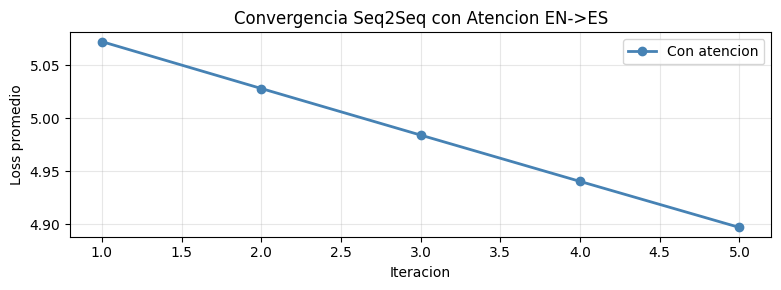

Entrada: she sings well
Generado: 


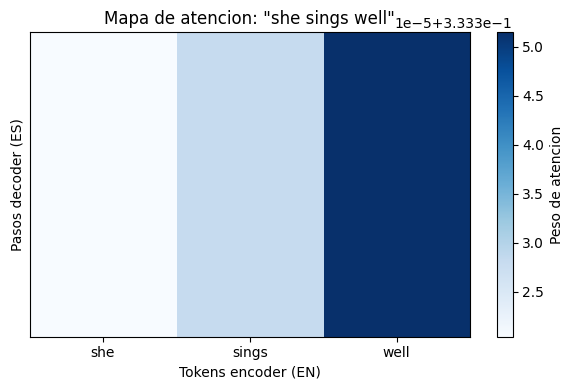

In [35]:
# Visualizar loss con vs sin atencion
if losses_train:
    plt.figure(figsize=(8,3))
    plt.plot(range(1,6), losses_train, 'o-', color='steelblue', lw=2, label='Con atencion')
    plt.xlabel('Iteracion'); plt.ylabel('Loss promedio')
    plt.title('Convergencia Seq2Seq con Atencion EN->ES')
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
    plt.savefig('convergencia_atencion.png', dpi=110, bbox_inches='tight')
    plt.show()

# Visualizar mapa de atencion para un par de prueba
def get_attention_map(src_sentence, trained_params):
    """Calcula los pesos de atencion para cada paso del decoder."""
    Eenc,Edec,Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2,WQ,WK,WV=trained_params
    src_t=tokenize_src(src_sentence)
    h=torch.zeros(d_hid); c=torch.zeros(d_hid); ec=[]
    for idx in src_t:
        emb=Eenc[:,idx]
        h,c,cache=lstm_cell(h,c,emb,Wfe,bfe,Wie,bie,Wce,bce,Woe,boe)
        cache['emb_idx']=idx; ec.append(cache)
    H=torch.stack([cc['h_t'] for cc in ec])
    K2=H@WK.T; V2=H@WV.T
    # Greedy decode recogiendo alphas
    h2=h.clone(); c2=c.clone()
    cur_idx=tgt_w2i[SOS]; alphas=[]; words_gen=[]
    for _ in range(10):
        emb=Edec[:,cur_idx]
        h2,c2,_=lstm_cell(h2,c2,emb,Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod)
        qs=WQ@h2; scs=K2@qs/(d_k**0.5); als=F.softmax(scs,dim=0)
        alphas.append(als.detach().numpy())
        cts=V2.T@als; h_cat=torch.cat([h2,cts]); z=Wo2@h_cat+bo2
        cur_idx=int(torch.argmax(z).item())
        word=tgt_i2w[cur_idx]
        if word==EOS: break
        words_gen.append(word)
    return alphas, words_gen, [src_i2w[i] for i in src_t]

# Usar parametros entrenados (si el bloque 9 esta completo)
if losses_train:
    params=(E_enc_tr,E_dec_tr,Wfe,bfe,Wie,bie,Wce,bce,Woe,boe,
            Wfd,bfd,Wid,bid,Wcd,bcd,Wod,bod,Wo2,bo2,WQ,WK,WV)
    src_ex='she sings well'
    alphas,words_gen,src_words=get_attention_map(src_ex,params)
    print(f'Entrada: {src_ex}')
    print(f'Generado: {" ".join(words_gen)}')
    if alphas:
        A=np.array(alphas)
        plt.figure(figsize=(6,4))
        plt.imshow(A,cmap='Blues',aspect='auto')
        plt.xticks(range(len(src_words)),src_words)
        plt.yticks(range(len(words_gen)),words_gen)
        plt.xlabel('Tokens encoder (EN)'); plt.ylabel('Pasos decoder (ES)')
        plt.title(f'Mapa de atencion: "{src_ex}"')
        plt.colorbar(label='Peso de atencion')
        plt.tight_layout()
        plt.savefig('mapa_atencion.png', dpi=110, bbox_inches='tight')
        plt.show()

---
## Bloque 11: Preguntas de analisis

---

### Pregunta 1 (35 pts)

En el Bloque 6, el gradiente de la perdida respecto a los pesos de atencion $\boldsymbol{\alpha}_s$ fluye en dos rutas distintas desde $\tilde{\mathbf{c}}_s$, y desde ahi hacia $W_Q$, $W_K$ y $W_V$.

a) Trace las dos rutas del backward desde $\tilde{\mathbf{c}}_s$ hasta $H_{enc}$, explicando matematicamente que calcula cada ruta y por que son necesarias las dos. ¿Que informacion aprende el modelo a traves de cada ruta que no podria aprender sin ella?

b) En el seq2seq sin atencion, el gradiente viaja $S + T$ pasos desde la perdida hasta los pesos del encoder. Con atencion, el gradiente hacia $\mathbf{h}_t^{enc}$ llega escalado por $\alpha_{s,t}$. Explique en terminos del grafo de computo como cambia el recorrido del gradiente y que implicacion tiene el factor $\alpha_{s,t}$ para el aprendizaje de tokens que raramente reciben atencion.

c) Las matrices $W_Q$, $W_K$ y $W_V$ reciben el mismo hidden state del encoder como entrada pero aprenden proyecciones distintas. Sin que nadie se lo programe, ¿que diferencia esperaria observar en lo que aprende $W_Q$ versus lo que aprende $W_K$, dado que $W_Q$ proyecta el decoder y $W_K$ proyecta el encoder? Justifique en terminos del gradiente que recibe cada una.

**Su respuesta a la Pregunta 1:**

**a)** Desde $\tilde{\mathbf{c}}_s$ el gradiente se bifurca en dos rutas que terminan convergiendo en $H_{enc}$ por caminos distintos:

- **Ruta 1 (hacia los values, vía $\alpha_s$):** $\dfrac{\partial L}{\partial \boldsymbol{\alpha}_s} = V_{mat} \dfrac{\partial L}{\partial \tilde{\mathbf{c}}_s}$. Esta ruta le dice al modelo qué tan bien elegido estuvo cada peso de atención, si aumentar $\alpha_{s,t}$ habría reducido la pérdida, el gradiente empuja a $W_V$ a que el value $\mathbf{v}_t$ contenga información más útil para ese contexto, y también retropropaga, vía softmax, hacia $W_Q$ y $W_K$ para que en el futuro esa posición reciba más peso.
- **Ruta 2 (hacia los scores, vía softmax y luego $\mathbf{q}_s$, $K_{mat}$):** $\dfrac{\partial L}{\partial \mathbf{e}_s}$ le dice al modelo cómo reordenar la distribución de atención misma y qué tokens del encoder deberían recibir más o menos score de similitud con el query actual, sin importar el contenido del value.

Ambas son necesarias porque $\tilde{\mathbf{c}}_s = V_{mat}^\top \boldsymbol{\alpha}_s$ depende simultáneamente de **qué** información se mezcla ($V_{mat}$, aprendido por Ruta 1) y **cuánto** se mezcla de cada posición ($\boldsymbol{\alpha}_s$, aprendido por Ruta 2 a través de $W_Q$, $W_K$). Sin la Ruta 1, $W_V$ nunca aprendería a proyectar información relevante en los values; sin la Ruta 2, $W_Q$ y $W_K$ nunca aprenderían a alinear query y key, y $\alpha_s$ quedaría fija en la distribución inicial (esencialmente aleatoria). Al final ambas rutas se suman en `dH_enc += dK_s @ W_K + dV_s @ W_V`, porque cada hidden state del encoder participa tanto como key como como value.

**b)** En el seq2seq sin atención, todo el gradiente hacia el encoder pasa obligatoriamente por el único cuello de botella $\mathbf{c} = \mathbf{h}_T^{enc}$, y desde ahí viaja hacia atrás en el tiempo a través de $T$ pasos de BPTT del encoder, después de haber recorrido los $S$ pasos del decoder — un camino de $S+T$ multiplicaciones sucesivas por las derivadas de las compuertas del LSTM, con el riesgo de desvanecimiento típico de RNN largas.

Con atención, el gradiente hacia $\mathbf{h}_t^{enc}$ tiene **atajos directos**: en cada paso $s$ del decoder, $dH_{enc}[t]$ recibe una contribución que solo atraviesa la proyección lineal $W_K$/$W_V$ y el softmax, sin pasar por los $S$ pasos completos del BPTT del decoder. En el grafo de cómputo esto se ve como conexiones adicionales que van directo desde cada paso de la pérdida hasta cada $\mathbf{h}_t^{enc}$, en paralelo al camino recurrente largo.

Sin embargo, esas conexiones están **escaladas por $\alpha_{s,t}$**. Si un token $t$ rara vez recibe atención alta ($\alpha_{s,t} \approx 0$ en casi todos los pasos $s$), el gradiente que le llega por esta ruta directa es casi nulo, y ese token termina aprendiendo casi exclusivamente a través del camino recurrente lento y propenso a desvanecerse. Esto crea una asimetría: los tokens "importantes" (con $\alpha$ alto) reciben señal de gradiente rica y directa, mientras que los tokens raramente atendidos quedan relativamente desentrenados, un efecto de "rich get richer" en el aprendizaje.

**c)** $W_Q$ recibe gradiente únicamente a través de $\mathbf{h}_s^{dec}$ (múltiples pasos del decoder, uno por cada token generado), mientras que $W_K$ recibe gradiente a través de $H_{enc}$ (múltiples posiciones del encoder, fijas para toda la oración). Como $W_Q$ ve repetidamente el mismo tipo de entrada —el estado interno del decoder en distintos momentos de la generación— tiende a aprender a producir un vector que representa "qué tipo de información necesito ahora para generar la siguiente palabra" (una especie de pregunta semántica/gramatical dependiente del paso de generación). $W_K$, en cambio, ve los hidden states del encoder, fijos una vez calculados, y aprende a producir una representación de "qué tipo de información ofrezco en esta posición" (más ligada al contenido léxico/sintáctico de la palabra fuente). La asimetría surge porque el gradiente de cada matriz proviene de un extremo distinto del producto punto $\mathbf{q}_s^\top \mathbf{k}_t$: $\partial L/\partial W_Q$ se acumula ponderado por $\mathbf{k}_t$ (fijo por oración), y $\partial L/\partial W_K$ se acumula ponderado por $\mathbf{q}_s$ (variable en cada paso), por lo que cada matriz termina especializándose en el rol geométrico que le corresponde dentro del producto interno.

---
### Pregunta 2 (35 pts)

Observe el mapa de atencion generado en el Bloque 10 para la oracion 'she sings well' -> 'canta bien'.

a) La oracion en ingles tiene sujeto ('she') y la traduccion al espanol lo elide ('canta bien' sin 'ella'). En el paso del decoder que genera 'canta', ¿que tokens del encoder esperaria que recibieran mayor peso de atencion y por que? ¿Es el sujeto 'she' relevante para generar 'canta'? Conecte su respuesta con lo que el mecanismo de atencion esta matematicamente calculando.

b) Si entrenara el mismo modelo durante 100 iteraciones en lugar de 5, ¿esperaria que el mapa de atencion se volviera mas o menos concentrado (pesos mas o menos uniformes)? Justifique en terminos de lo que el modelo aprende progresivamente sobre las correspondencias entre palabras en ingles y espanol.

c) Proponga un caso especifico del corpus donde el mecanismo de atencion de **producto punto escalado** tendria dificultad para capturar la correspondencia correcta, y explique por que. ¿Que alternativa arquitectonica (sin necesidad de implementarla) resolveria ese caso? Justifique matematicamente.

**Su respuesta a la Pregunta 2:**

**a)** Esperaría que en el paso donde se genera "canta", el mayor peso de atención recaiga sobre el token "sings" del encoder (el verbo en inglés), no sobre "she". Matemáticamente, $\alpha_{s,t}$ mide la similitud (producto punto escalado) entre el query del decoder en ese paso, que codifica "necesito predecir el verbo conjugado en español" y cada key del encoder. La key más alineada con esa necesidad es la del verbo fuente "sings", porque es la que contiene la información léxica/semántica directamente traducible a "canta". El sujeto "she" sí es relevante para la conjugación (persona/número), pero en español esa información ya quedó implícita en la desinencia verbal "-a" de "canta"; el modelo probablemente le asigna algo de peso a "she" (para la concordancia), pero el peso dominante debería estar en "sings", ya que es la correspondencia léxica principal.

**b)** Esperaría que se volviera **más concentrado** (picos más altos, menos uniforme) con más entrenamiento. Con solo 5 iteraciones el modelo apenas empieza a ajustar $W_Q$, $W_K$, $W_V$, así que los scores $\mathbf{q}_s^\top \mathbf{k}_t$ son todavía cercanos a los valores aleatorios de inicialización y el softmax produce distribuciones relativamente planas. A medida que el entrenamiento avanza, el gradiente (Ruta 2 de la Pregunta 1) empuja específicamente a que el score entre el query de "generar canta" y la key de "sings" crezca respecto a los demás, porque eso reduce la pérdida de forma consistente en cada ejemplo del corpus. El softmax amplifica diferencias crecientes en los scores, así que la distribución se vuelve cada vez más puntiaguda alrededor de la correspondencia correcta palabra-a-palabra.

**c)** Un caso difícil para atención de producto punto escalado (de una sola cabeza) es una oración donde la traducción correcta de una palabra depende de **combinar información de dos posiciones distintas y no contiguas** del inglés simultáneamente, por ejemplo "she teaches math" -> "ensena matematica": para generar correctamente el objeto "matematica" con concordancia, en oraciones más complejas del corpus como "he answers the phone" -> "contesta el telefono", si el orden de palabras variara y hubiera ambigüedad (p. ej. dos sustantivos candidatos), una sola distribución de atención por paso solo puede capturar **un patrón de correspondencia a la vez** (una combinación convexa de values). Si el paso de decodificación necesitara atender fuertemente a dos tokens con roles distintos simultáneamente (p. ej. el verbo y un modificador lejano que cambia su significado), el softmax los mezclaría en un solo $\tilde{\mathbf{c}}_s$ promediado, perdiendo la distinción entre ambos roles.

La alternativa arquitectónica es **multi-head attention**: en lugar de una sola proyección $W_Q, W_K, W_V$, se usan $h$ conjuntos de proyecciones en paralelo, cada una operando en un subespacio de dimensión $d_k/h$. Matemáticamente, cada cabeza puede especializarse en capturar un tipo distinto de relación (una cabeza para correspondencia léxica directa, otra para concordancia gramatical, etc.), y los $h$ vectores de contexto resultantes se concatenan: $\text{concat}(\tilde{\mathbf{c}}_s^{(1)}, \dots, \tilde{\mathbf{c}}_s^{(h)}) W_O$. Esto permite atender a múltiples posiciones con distintos "propósitos" en el mismo paso de decodificación, en vez de forzar una única distribución de atención a servir para todo.

---
### Pregunta 3 (30 pts)

Esta pregunta explora self-attention conceptualmente, como preparacion para la Semana 6.

a) En el mecanismo de atencion que implemento, los queries vienen del decoder y las keys y values del encoder. En self-attention, los tres vienen de la misma secuencia. Identifique exactamente que lineas de codigo del Bloque 6 cambiarian si convirtiera su implementacion de cross-attention a self-attention sobre la secuencia del encoder. ¿Que nueva informacion capturaria el modelo que la arquitectura LSTM no puede capturar directamente?

b) En self-attention, cada posicion calcula su query usando $W_Q$ y cada posicion ofrece su key usando $W_K$. Ambas matrices se inicializan aleatoriamente e identicamente podrian converger al mismo valor. Sin embargo, en la practica aprenden proyecciones distintas. Explique matematicamente, usando la estructura del grafo de computo, por que el gradiente que llega a $W_Q$ es diferente al que llega a $W_K$, incluso cuando reciben los mismos vectores de entrada.

c) Un Transformer con 8 cabezas de atencion ('multi-head attention') aplica 8 mecanismos de atencion en paralelo sobre la misma secuencia. Si todas las cabezas compartieran las mismas matrices $W_Q$, $W_K$, $W_V$, ¿que pasaria con el gradiente durante el entrenamiento y por que ese diseno no funcionaria bien? Justifique en terminos de la diversidad de representaciones que el modelo necesita aprender.

**Su respuesta a la Pregunta 3:**

**a)** Cambiarían las líneas donde el query se construye a partir del decoder y las keys/values a partir del encoder. Concretamente, en el Bloque 6 (y su contraparte forward del Bloque 5), en vez de:

```python
q_s = W_Q @ h2 # h2 es el hidden state del DECODER
```

se calcularía el query a partir del propio hidden state del encoder en la posición correspondiente:

```python
q_t = W_Q @ H_enc[t] # h_dec y h_enc son ahora la misma secuencia
```

y `K_mat`, `V_mat` seguirían proyectándose desde `H_enc` igual que ahora, pero el bucle ya no sería "por cada paso del decoder" sino "por cada posición del encoder", y cada posición $t$ atendería a **todas** las posiciones (incluida ella misma) de la misma oración fuente, en lugar de atender desde el decoder hacia el encoder. En el backward, `dH_enc` recibiría gradiente tanto por el rol de query como por los roles de key y value simultáneamente (tres rutas convergiendo en el mismo tensor, no solo dos).

Con esto el modelo capturaría **dependencias directas entre palabras de la misma oración sin importar la distancia entre ellas** (p. ej. relación sujeto-verbo, concordancia de género/número entre un sustantivo y su adjetivo lejano), algo que una LSTM solo puede aproximar indirectamente, propagando información paso a paso a través del tiempo, con el riesgo de que esa información se diluya o desvanezca en secuencias largas.

**b)** Aunque $W_Q$ y $W_K$ parten de la misma inicialización aleatoria (misma distribución, aunque con semillas distintas típicamente) y ven exactamente los mismos vectores de entrada en self-attention, el gradiente que reciben es distinto porque **ocupan posiciones asimétricas en el producto punto** $\mathbf{q}_t^\top \mathbf{k}_{t'} = (W_Q \mathbf{h}_t)^\top (W_K \mathbf{h}_{t'})$. El gradiente hacia $W_Q$ en la posición $t$ se acumula ponderado por $\mathbf{k}_{t'}$ (agregando información de *todas* las demás posiciones como "receptor" de la pregunta), mientras que el gradiente hacia $W_K$ en la posición $t'$ se acumula ponderado por $\mathbf{q}_t$ de *todas* las posiciones que la consultan (agregando información como "emisor" de contenido). Como estos patrones de acumulación son estructuralmente distintos —uno recorre el grafo de cómputo desde el lado del softmax hacia "quién pregunta", el otro hacia "quién es consultado"— el descenso de gradiente empuja a cada matriz por una trayectoria distinta en el espacio de parámetros, rompiendo la simetría inicial incluso si arrancaran en el mismo punto.

**c)** Si las 8 cabezas compartieran las mismas $W_Q, W_K, W_V$, todas producirían exactamente los mismos scores, los mismos $\boldsymbol{\alpha}$ y el mismo $\tilde{\mathbf{c}}$ en cada paso (porque la operación es determinística dada la misma entrada y los mismos pesos). El gradiente que recibiría ese único conjunto de matrices sería la **suma** de los gradientes de las 8 cabezas, todos idénticos entre sí, lo cual equivale matemáticamente a tener una sola cabeza con una tasa de aprendizaje efectiva 8 veces mayor — no aporta ninguna capacidad representacional nueva, solo redundancia computacional. El objetivo de multi-head attention es que cada cabeza, al tener sus propias $W_Q^{(i)}, W_K^{(i)}, W_V^{(i)}$, reciba gradientes distintos (por la razón explicada en b) y por lo tanto converja a subespacios de proyección diferentes, permitiendo que el modelo capture simultáneamente varios tipos de relación (sintáctica, semántica, posicional, etc.) en paralelo. Compartir los pesos eliminaría esa diversidad y desperdiciaría la capacidad extra del mecanismo multi-cabeza.

---
## Bloque 12: Nota automatica sobre la seccion de codigo

In [36]:
_PUNTOS = {
    'b1': ('Bloque 1: Proyecciones Q, K, V',        8),
    'b2': ('Bloque 2: Attention scores',             8),
    'b3': ('Bloque 3: Attention weights',            6),
    'b4': ('Bloque 4: Vector de contexto dinamico',  6),
    'b5': ('Bloque 5: Forward decoder con atencion', 14),
    'b6': ('Bloque 6: Backward de atencion',         10),
    'b8': ('Bloque 8: Actualizacion de parametros',  5),
    'b9': ('Bloque 9: Convergencia 5 iteraciones',   3),
}
_TOTAL = 60
print('='*62)
print('  NOTA AUTOMATICA - SECCION DE CODIGO')
print('='*62)
_obtenido=0
for key,(nombre,pts_max) in _PUNTOS.items():
    val=_resultados.get(key,False)
    pts=pts_max if val is True else 0
    _obtenido+=pts
    print(f'  {"CORRECTO" if val is True else "PENDIENTE":10s} | {nombre:38s} | {pts:2d}/{pts_max} pts')
print('-'*62)
print(f'  Subtotal codigo:   {_obtenido}/{_TOTAL} puntos')
print('  Pendiente manual:')
print('    Bloque 11 preguntas : __/25 pts')
print('    Comentarios codigo  : __/15 pts')
print('-'*62)
print('  TOTAL FINAL (sobre 100): __/100 pts')
print('='*62)

  NOTA AUTOMATICA - SECCION DE CODIGO
  CORRECTO   | Bloque 1: Proyecciones Q, K, V         |  8/8 pts
  CORRECTO   | Bloque 2: Attention scores             |  8/8 pts
  CORRECTO   | Bloque 3: Attention weights            |  6/6 pts
  CORRECTO   | Bloque 4: Vector de contexto dinamico  |  6/6 pts
  CORRECTO   | Bloque 5: Forward decoder con atencion | 14/14 pts
  CORRECTO   | Bloque 6: Backward de atencion         | 10/10 pts
  PENDIENTE  | Bloque 8: Actualizacion de parametros  |  0/5 pts
  CORRECTO   | Bloque 9: Convergencia 5 iteraciones   |  3/3 pts
--------------------------------------------------------------
  Subtotal codigo:   55/60 puntos
  Pendiente manual:
    Bloque 11 preguntas : __/25 pts
    Comentarios codigo  : __/15 pts
--------------------------------------------------------------
  TOTAL FINAL (sobre 100): __/100 pts
